# NB02 — Species × System Matrix

**Purpose**: Aggregate the raw defense-cluster hits from NB01 to a species-level
presence/absence matrix (7 systems × 27K species), apply broad-Pfam
co-occurrence filtering (Retron & DISARM), and attach covariates (phylum,
genome size, no_genomes) needed for the arms-race and syndrome analyses.

**Broad-Pfam filtering rules** (from `RESEARCH_PLAN.md`):
- **Retron** (RVT_1 alone is broad): call `retron_candidate` (present) vs
  `retron_stringent` (present AND ≥1 other narrow defense system in same species).
- **DISARM** (DrmC PLD & DrmB SNF2 both broad): call `disarm_present` only if
  BOTH markers are present in the species pangenome.

**Output**: `data/species_defense_matrix.tsv.gz` and
`figures/system_prevalence_by_phylum.png`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from berdl_notebook_utils.setup_spark_session import get_spark_session

spark = get_spark_session()

DATA_DIR = "../data"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load NB01 output and pangenome covariates

In [2]:
hits = pd.read_csv(os.path.join(DATA_DIR, "defense_gene_clusters.tsv.gz"), sep="\t")
print(f"Hits: {len(hits):,} rows, {hits['gtdb_species_clade_id'].nunique():,} unique species")
hits.head(3)

Hits: 930,573 rows, 27,626 unique species


,gene_cluster_id,gtdb_species_clade_id,is_core,is_auxiliary,is_singleton,system,subtype,marker,is_broad,source
0,JAIPKA010000062.1_8,s__Cephaloticoccus_sp021734075--GB_GCA_0217340...,True,False,False,DISARM,any,PF00176,True,interproscan_pfam
1,NZ_JODG01000493.1_1,s__Streptomyces_spiralis--RS_GCF_014654675.1,False,True,True,CRISPR-Cas,Type V,PF07282,False,interproscan_pfam
2,NZ_JAFGYY010000011.1_24,s__Pseudomonas_sp017491605--RS_GCF_017491605.1,True,False,False,DISARM,any,PF00176,True,interproscan_pfam


In [3]:
# Species-level covariates: phylum, genome_size (median across species genomes),
# no_genomes (species-clade count), total_clusters (pangenome cluster count).
# NOTE: gtdb_metadata.genome_size is STRING — CAST to DOUBLE first.
covariates = spark.sql("""
    WITH species_size AS (
        SELECT g.gtdb_species_clade_id,
               CAST(gm.genome_size AS DOUBLE) AS genome_size_num
        FROM kbase_ke_pangenome.gtdb_metadata gm
        JOIN kbase_ke_pangenome.genome g
          ON gm.accession = g.genome_id
        WHERE gm.genome_size IS NOT NULL
    ),
    species_size_agg AS (
        SELECT gtdb_species_clade_id,
               PERCENTILE_APPROX(genome_size_num, 0.5) AS median_genome_size,
               COUNT(*) AS n_genomes_metadata
        FROM species_size
        GROUP BY gtdb_species_clade_id
    ),
    -- genome.gtdb_taxonomy_id is truncated at genus; gtdb_taxonomy_r214v1.gtdb_taxonomy_id
    -- includes species. Direct join fails. Parse phylum from the taxonomy string instead.
    species_phylum_counts AS (
        SELECT g.gtdb_species_clade_id,
               REGEXP_EXTRACT(g.gtdb_taxonomy_id, 'p__([^;]+)', 1) AS phylum,
               COUNT(*) AS n
        FROM kbase_ke_pangenome.genome g
        WHERE g.gtdb_taxonomy_id IS NOT NULL
        GROUP BY g.gtdb_species_clade_id, phylum
    ),
    species_phylum AS (
        SELECT gtdb_species_clade_id, phylum
        FROM (
            SELECT gtdb_species_clade_id, phylum, n,
                   ROW_NUMBER() OVER (PARTITION BY gtdb_species_clade_id ORDER BY n DESC) AS rk
            FROM species_phylum_counts
        ) t
        WHERE rk = 1
    )
    SELECT sa.gtdb_species_clade_id,
           sa.median_genome_size,
           sa.n_genomes_metadata,
           pg.no_genomes,
           pg.no_gene_clusters AS n_clusters,
           sp.phylum
    FROM species_size_agg sa
    LEFT JOIN kbase_ke_pangenome.pangenome pg
      ON sa.gtdb_species_clade_id = pg.gtdb_species_clade_id
    LEFT JOIN species_phylum sp
      ON sa.gtdb_species_clade_id = sp.gtdb_species_clade_id
""").toPandas()
print(f"Covariates rows: {len(covariates):,}")
covariates.head(3)

Covariates rows: 27,690


,gtdb_species_clade_id,median_genome_size,n_genomes_metadata,no_genomes,n_clusters,phylum
0,s__01-FULL-36-15b_sp001782035--GB_GCA_001782035.1,725899.0,2,2,826,Patescibacteria
1,s__1-14-0-10-31-34_sp018829335--GB_GCA_0188293...,1298137.0,2,2,2084,Iainarchaeota
2,s__1-14-0-10-45-20_sp007378985--GB_GCA_0073789...,727695.0,3,3,1282,Patescibacteria


## 2. Aggregate hits to per-species per-system counts

Long-form: (species, system, n_clusters, n_core, n_auxiliary, n_singleton).
Keep the "is_broad" flag so we can split broad vs specific in step 3.

In [4]:
per_species_system = (
    hits.groupby(["gtdb_species_clade_id", "system"], as_index=False)
    .agg(
        n_clusters=("gene_cluster_id", "nunique"),
        n_core=("is_core", lambda s: int(s.sum())),
        n_auxiliary=("is_auxiliary", lambda s: int(s.sum())),
        n_singleton=("is_singleton", lambda s: int(s.sum())),
    )
)
print(f"per-species-per-system rows: {len(per_species_system):,}")
per_species_system.head(6)

per-species-per-system rows: 128,012


,gtdb_species_clade_id,system,n_clusters,n_core,n_auxiliary,n_singleton
0,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,BREX,5,5,0,0
1,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,CRISPR-Cas,20,17,8,7
2,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,DISARM,6,6,2,2
3,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,R-M Type I,7,1,6,3
4,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,R-M Type II,1,0,1,1
5,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,Retron,6,0,6,4


## 3. Apply broad-Pfam co-occurrence filtering

### Retron
Compute two flags: `retron_candidate` (RVT_1 present) and `retron_stringent`
(RVT_1 present AND species has ≥1 other narrow defense system).

### DISARM
Require BOTH PF13091 (DrmC PLD) AND PF00176 (DrmB SNF2) in the species pangenome.

In [5]:
# NARROW systems: everything except Retron and DISARM
NARROW_SYSTEMS = ["CRISPR-Cas", "R-M Type I", "R-M Type II", "CBASS", "Gabija", "BREX"]

species_narrow_ct = (
    per_species_system[per_species_system["system"].isin(NARROW_SYSTEMS)]
    .groupby("gtdb_species_clade_id")["system"]
    .nunique()
    .rename("n_narrow_systems")
    .reset_index()
)

# For DISARM: check both markers present
disarm_markers = (
    hits[hits["system"] == "DISARM"]
    .groupby("gtdb_species_clade_id")["marker"]
    .apply(set)
    .rename("disarm_marker_set")
    .reset_index()
)
disarm_markers["disarm_present"] = disarm_markers["disarm_marker_set"].apply(
    lambda s: ("PF13091" in s) and ("PF00176" in s)
)

# For Retron: RVT_1 present = candidate; stringent = also has narrow system
retron_species = set(per_species_system.loc[per_species_system["system"] == "Retron",
                                            "gtdb_species_clade_id"])
print(f"Retron candidate species (RVT_1 present): {len(retron_species):,}")
print(f"DISARM species (both DrmB+DrmC): {int(disarm_markers['disarm_present'].sum()):,}")

Retron candidate species (RVT_1 present): 15,109
DISARM species (both DrmB+DrmC): 16,144


## 4. Build the wide species × system presence matrix

In [6]:
# All species observed in the hits
all_species = sorted(hits["gtdb_species_clade_id"].unique())
print(f"Species with any defense hit: {len(all_species):,}")

# Narrow systems: presence = at least one gene cluster hit
narrow_presence = (
    per_species_system[per_species_system["system"].isin(NARROW_SYSTEMS)]
    .assign(present=1)
    .pivot_table(index="gtdb_species_clade_id", columns="system", values="present", fill_value=0)
    .astype(int)
)
narrow_presence.columns.name = None

# Assemble the full matrix
matrix = pd.DataFrame({"gtdb_species_clade_id": all_species}).set_index("gtdb_species_clade_id")
for sys in NARROW_SYSTEMS:
    matrix[sys] = narrow_presence.reindex(matrix.index).get(sys, 0).fillna(0).astype(int)

# DISARM: strict (both markers)
disarm_map = disarm_markers.set_index("gtdb_species_clade_id")["disarm_present"].to_dict()
matrix["DISARM"] = matrix.index.map(lambda x: int(disarm_map.get(x, False)))

# Retron: candidate + stringent
matrix["Retron_candidate"] = matrix.index.map(lambda x: int(x in retron_species))
narrow_ct_map = species_narrow_ct.set_index("gtdb_species_clade_id")["n_narrow_systems"].to_dict()
matrix["Retron_stringent"] = matrix.index.map(
    lambda x: int((x in retron_species) and (narrow_ct_map.get(x, 0) >= 1))
)

# Total defense system count (using strict/stringent variants)
system_cols_strict = NARROW_SYSTEMS + ["DISARM", "Retron_stringent"]
matrix["n_defense_systems"] = matrix[system_cols_strict].sum(axis=1)

# Also record: n_narrow_systems (excluding Retron/DISARM) for QC
matrix["n_narrow_systems"] = matrix[NARROW_SYSTEMS].sum(axis=1)

# Merge covariates
matrix = matrix.reset_index().merge(covariates, on="gtdb_species_clade_id", how="left")
print(f"Matrix rows: {len(matrix):,}")
print(f"Species with at least 1 defense system (strict): {(matrix['n_defense_systems'] >= 1).sum():,}")
matrix.head(3)

Species with any defense hit: 27,626
Matrix rows: 27,626
Species with at least 1 defense system (strict): 27,565


,gtdb_species_clade_id,CRISPR-Cas,R-M Type I,R-M Type II,CBASS,Gabija,BREX,DISARM,Retron_candidate,Retron_stringent,n_defense_systems,n_narrow_systems,median_genome_size,n_genomes_metadata,no_genomes,n_clusters,phylum
0,s__0-14-0-80-60-11_sp018897875--GB_GCA_0188978...,1,1,1,0,0,1,1,1,1,6,4,4009362.0,3.0,3.0,5504.0,Desulfobacterota
1,s__0-14-3-00-41-53_sp002780895--GB_GCA_0027808...,1,1,1,0,0,1,1,1,1,6,4,1986433.0,7.0,7.0,3349.0,Nitrospirota
2,s__01-FULL-36-15b_sp001782035--GB_GCA_001782035.1,1,0,0,0,0,0,0,0,0,1,1,725899.0,2.0,2.0,826.0,Patescibacteria


## 5. Prevalence by system

In [7]:
prev_summary = pd.DataFrame({
    "system": system_cols_strict + ["Retron_candidate"],
    "n_species_present": [int(matrix[c].sum()) for c in system_cols_strict + ["Retron_candidate"]],
    "pct_species_present": [round(100.0 * matrix[c].sum() / len(matrix), 2)
                            for c in system_cols_strict + ["Retron_candidate"]],
})
prev_summary.sort_values("pct_species_present", ascending=False, inplace=True)
prev_summary

,system,n_species_present,pct_species_present
0,CRISPR-Cas,26535,96.05
5,BREX,22116,80.06
1,R-M Type I,21216,76.80
6,DISARM,16144,58.44
8,Retron_candidate,15109,54.69
7,Retron_stringent,15098,54.65
2,R-M Type II,10738,38.87
4,Gabija,6287,22.76
3,CBASS,1974,7.15


## 6. Prevalence by phylum

Restrict to species with `no_genomes >= 5` for reliable pangenome calls,
and to phyla with at least 100 species in that filtered set.

Species with no_genomes >= 5: 7,323
Phyla with >=100 species (n>=5): 9


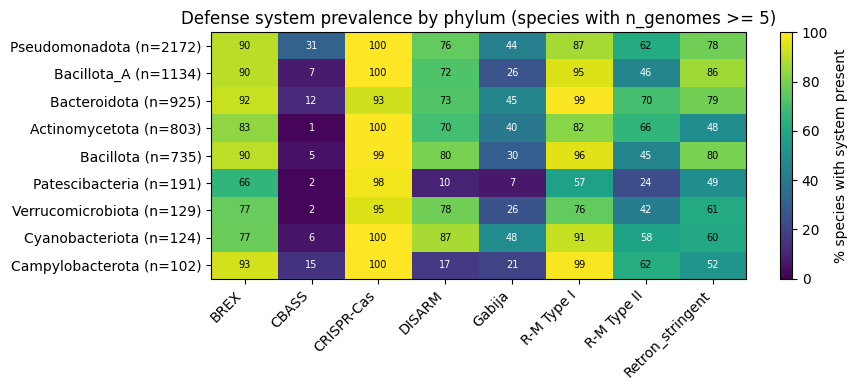

Saved: ../figures/system_prevalence_by_phylum.png


In [8]:
ge5 = matrix[matrix["no_genomes"] >= 5].copy()
print(f"Species with no_genomes >= 5: {len(ge5):,}")

phy_size = ge5["phylum"].value_counts()
big_phyla = phy_size[phy_size >= 100].index.tolist()
print(f"Phyla with >=100 species (n>=5): {len(big_phyla)}")

phyla_stats = []
for phylum in big_phyla:
    sub = ge5[ge5["phylum"] == phylum]
    n = len(sub)
    for sys in system_cols_strict:
        pct = 100.0 * sub[sys].sum() / n
        phyla_stats.append({"phylum": phylum, "system": sys, "pct_present": pct, "n_species": n})
phy_df = pd.DataFrame(phyla_stats)

heat = phy_df.pivot(index="phylum", columns="system", values="pct_present")
heat = heat.loc[phy_size.loc[big_phyla].index]  # order by phylum size

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(big_phyla))))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=0, vmax=100)
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels([f"{p} (n={phy_size[p]})" for p in heat.index])
ax.set_title("Defense system prevalence by phylum (species with n_genomes >= 5)")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        color = "white" if v < 60 else "black"
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color=color)
plt.colorbar(im, ax=ax, label="% species with system present")
plt.tight_layout()
outfig = os.path.join(FIG_DIR, "system_prevalence_by_phylum.png")
plt.savefig(outfig, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {outfig}")

## 7. Save the matrix

In [9]:
out = os.path.join(DATA_DIR, "species_defense_matrix.tsv.gz")
matrix.to_csv(out, sep="\t", index=False, compression="gzip")
print(f"Wrote: {out}")
print(f"Rows: {len(matrix):,}")
print(f"Columns: {list(matrix.columns)}")

Wrote: ../data/species_defense_matrix.tsv.gz
Rows: 27,626
Columns: ['gtdb_species_clade_id', 'CRISPR-Cas', 'R-M Type I', 'R-M Type II', 'CBASS', 'Gabija', 'BREX', 'DISARM', 'Retron_candidate', 'Retron_stringent', 'n_defense_systems', 'n_narrow_systems', 'median_genome_size', 'n_genomes_metadata', 'no_genomes', 'n_clusters', 'phylum']


## Summary

- Wide species × system matrix built (27K species × 7 systems + strict/stringent Retron variants).
- Retron `candidate` (RVT_1 alone) vs `stringent` (RVT_1 + another narrow system) both carried through.
- DISARM only called present when both DrmC PLD and DrmB SNF2 are in the species pangenome.
- Covariates (phylum, median_genome_size, no_genomes, n_clusters) attached.
- Prevalence-by-phylum heatmap saved.

**Next**:
- `03_prophage_burden.ipynb` — re-derive per-species prophage burden using
  `prophage_ecology`'s classifier.
- `04_arms_race.ipynb` — partial Spearman + neg-binom test.